# Testing the model on images

In [6]:
import sys
sys.path.append("..")
import YOLOtrack11
import os
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import PIL.ImageFile
from YOLOtrack11.results import ZAxisResults as Results
import PIL
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle,Circle
from importlib import reload
# from ultralytics.utils.metrics import box_iou
from scipy.optimize import linear_sum_assignment
import torch
from ultralytics.utils import ops
from itertools import repeat
from cv2 import resize
from matplotlib_scalebar.scalebar import ScaleBar

def plot_gt(path,ax,imgsz=[512,512],vmin=1.95e4,vmax=2.05e4):
    data=np.atleast_2d(np.loadtxt(path.replace("images", "labels").replace("jpg","txt").replace("tif","txt"))).T
    # print(data)
    if(len(data)==0):
         return plot_result(ax,path, np.empty(0),np.empty((0,4)),np.empty(0),np.empty((0,0)),vmin=vmin,vmax=vmax)
    cls = data[0]
    bboxes = data[1:5].T*(imgsz*2)
    z = data[5]
    kpts = data[7:].T*imgsz
    # print(bboxes)
    
    return plot_result(ax,path, cls,bboxes,z,kpts, vmin=vmin,vmax=vmax)

def tiflen(img):
    i=0
    while True:
        try:
            img.seek(i)
        except EOFError:
            return i
        i+=1

yundon_img = (-1,None) #img_idx, imgfile
imgpaths = ["BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0.ome.tif","BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0_1.ome.tif","BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0_2.ome.tif","BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0_3.ome.tif",]
imglengths = [tiflen(PIL.Image.open("../../../Pictures/" + imgpath)) for imgpath in imgpaths]
def open_yundon_img(idx):
    global yundon_img
    global imgpaths
    global imglengths
    for i,imglen in enumerate(imglengths): #find image index and relative index
        if idx >= imglen:
            idx -= imglen
        else: break

    if yundon_img[0] != i: #if correct image is not loaded:
        if isinstance(yundon_img[1], PIL.Image.Image): yundon_img[1].close() #close old image
        yundon_img = i,PIL.Image.open("../../../Pictures/"+imgpaths[i])

    yundon_img[1].seek(idx)
    return yundon_img[1]
        



def plot_gt_yundon(idx,ax):
    img = open_yundon_img(idx)
    x,y,z=np.loadtxt("../../../Pictures/TrackingResultBugs_4th_TrackingGroundTruthScript250213.csv", delimiter=",").T
    x/=0.325
    y/=0.325

    z -= 0.2676 * idx

    bx=by = (np.abs(z)/0.161*0.21+55)
    bboxes = np.array([x,y,bx,by]).T
    # z/=210 # convert to network scale
    mask = (z > -102) & (z < 108)
    # if(len(data)==0):
    #      return plot_result(ax,path, np.empty(0),np.empty((0,4)),np.empty(0),np.empty((0,0)))
    cls = np.zeros_like(x)
    
    kpts = np.array([x,y]).T
    # print(bboxes)
    print("Ground truth contains", len(z[mask]),"Ripples")
    
    return plot_result(ax,img, cls[mask],bboxes=bboxes[mask],z=z[mask],kpts=kpts[mask],imgsz=1)


     
def plot_result(ax,img,cls,bboxes=repeat(None),z=None,kpts=None, conf=None,vmin=1.95e4,vmax=2.05e4):
    is_conf = conf is not None
    if not is_conf:
         conf = np.zeros_like(cls)
    if isinstance(img, PIL.Image.Image):
        pass
    elif(type(img) == str):
        img = PIL.Image.open(img)
    print(vmin,vmax)
    ax.imshow(img,cmap="grey",vmin=vmin,vmax=vmax)
    ax.axis("off")
    for bbox,z_value,kpt,c in zip(bboxes,z, kpts,conf):
        if(bbox is not None):
            x,y,w,h = bbox
            rect = Rectangle((x-0.5*w,y-0.5*h),h,w, linewidth=1, edgecolor="yellow", facecolor='none')
            tx,ty = rect.get_xy()
            ax.add_patch(rect)
            tx+=6
            ty-=12
        else:
            tx,ty = kpt
            ty-=40
            tx-=50
        circle = Circle(kpt,1, facecolor="red",edgecolor="red")
        ax.add_patch(circle)
        ax.text(tx,ty,f"z={z_value:.3f}" + (f", {c*100:.0f}%" if is_conf else ""),fontsize="small",bbox=dict(facecolor='white', alpha=0.5,))

    return bboxes,z

      
def match_predictions(pred_bboxes, gt_bboxes, pred_classes, true_classes,threshold):

        iou = box_iou(torch.Tensor(gt_bboxes), torch.Tensor(pred_bboxes))

        correct = np.zeros((pred_classes.shape[0])).astype(bool)
        gt_pred_matches = np.zeros((true_classes.shape[0],pred_classes.shape[0] ), dtype=bool)
        # LxD matrix where L - labels (rows), D - detections (columns)
        correct_class = true_classes[:, None] == pred_classes
        iou = iou * correct_class  # zero out the wrong classes
        iou = iou.cpu().numpy()

        cost_matrix = iou * (iou >= threshold)
        if cost_matrix.any():
            labels_idx, detections_idx = linear_sum_assignment(cost_matrix, maximize=True)
            valid = cost_matrix[labels_idx, detections_idx] > 0
            if valid.any():
                correct[detections_idx[valid]] = True
                gt_pred_matches[labels_idx,detections_idx] = valid

        return correct, gt_pred_matches
def box_iou(box1, box2, eps=1e-7):

    (a1, a2), (b1, b2) = box1.float().unsqueeze(1).chunk(2, 2), box2.float().unsqueeze(0).chunk(2, 2)
    inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)

    # IoU = inter / (area1 + area2 - inter)
    return inter / ((a2 - a1).prod(2) + (b2 - b1).prod(2) - inter + eps)

In [7]:
type(YOLOtrack11.ultralytics.hub.SETTINGS)


ultralytics.utils.SettingsManager

In [15]:
# reload(results)
model = YOLOtrack11.YOLOtrack11("../../ultralytics/runs/pose/train122/weights/best.pt")
# print(model.model.model)
print("loaded")
dataset_path = "../datasets/Dataset_subpixel/images/test_real"
# dataset_path = "../ultralytics/data_gen/Dataset_hard/images/val"
imgsz=640,540
test_images = os.listdir(dataset_path)
random_image = lambda: dataset_path+"/"+test_images[np.random.randint(0,len(test_images))]

loaded



0: 544x640 56 Ripples, 8.1ms
Speed: 0.6ms preprocess, 8.1ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)


19500.0 20500.0
19500.0 20500.0


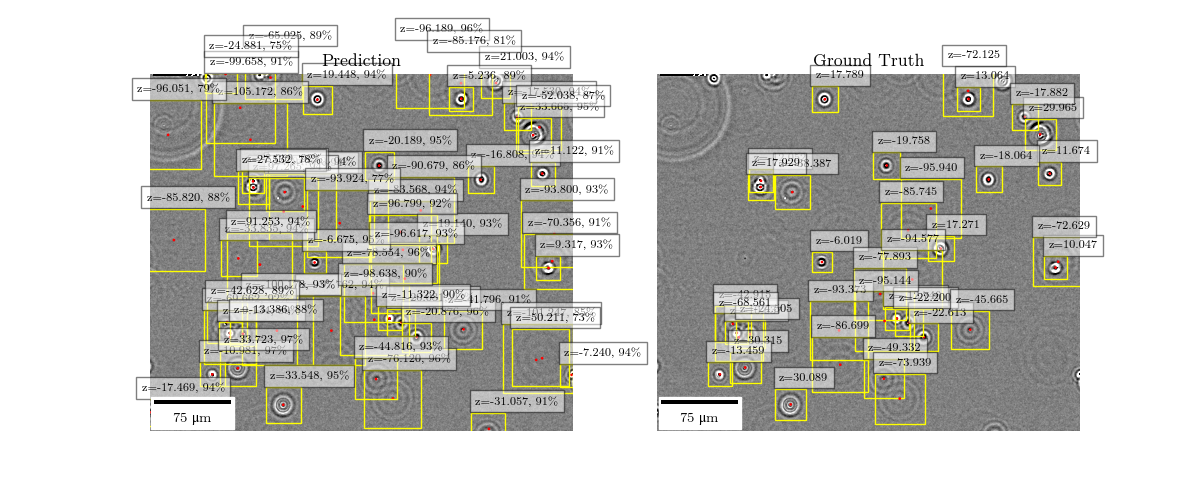

In [17]:
reload(YOLOtrack11)
%matplotlib widget 
if not plt.get_fignums() : plt.figure(figsize=(12,5))
else: plt.clf()
# idx = np.random.random_integers(0,1212)
# img = open_yundon_img(idx).copy()
# img= img.resize([640,540])
# img = np.array(img)
# print(img.shape)
image = random_image()
img = np.array(PIL.Image.open(image))
results = model.predict(np.array(img), conf = 0.7)
res = results[0].zaxis.data.cpu().numpy()
# kpts = results[0].keypoints.data.cpu().numpy()
# print(res)
plt.subplot(1,2,1)
plt.title("Prediction")
kpt = res[:,8:]
# kpt[:,1]-=2
bbox = res[:,:4]
# bbox[:,1::2]-=2
z = res[:,6]
# z = -(z *210 - 102)
plot_result(plt.gca(),img,res[:,4],ops.xyxy2xywh(bbox),z,kpt,conf=res[:,4])
scalebar = ScaleBar(4*0.161e-6, loc="lower left")
plt.gca().add_artist(scalebar)
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Ground Truth")
# plot_gt_yundon(idx, plt.gca())
# ops.scale_boxes((512,512), gt_bbox, ori_shape, ratio_pad=ratio_pad)  # native-space labels
gt_bboxes,gt_z_values = plot_gt(image,plt.gca(),imgsz)
# gt_z_values*=210
# true_bboxes = ops.xywh2xyxy(gt_bboxes) * np.array((512,512))[[1, 0, 1, 0]]  # target boxes
# _, gt_pred_matcher = match_predictions(res[:,:4],true_bboxes,np.zeros(len(res)),np.zeros(len(true_bboxes)),0.5)
# print("gt  :", gt_z_values[np.where(gt_pred_matcher.T)[1]])
# print("yolo:", res[:,-1])
# # print("corr:", np.array(corr))
# print("gt undetected:", gt_z_values[np.where(gt_pred_matcher.sum(1)==0)[0]])
scalebar = ScaleBar(4*0.161e-6, loc="lower left")
plt.gca().add_artist(scalebar)
plt.show()



In [6]:
img = PIL.Image.open("../../Pictures/BGC101_H2V2Z1_Ch1_zstack_1_MMStack_Pos0.ome.tif")
img.seek(100)

In [7]:
image = np.array(img)

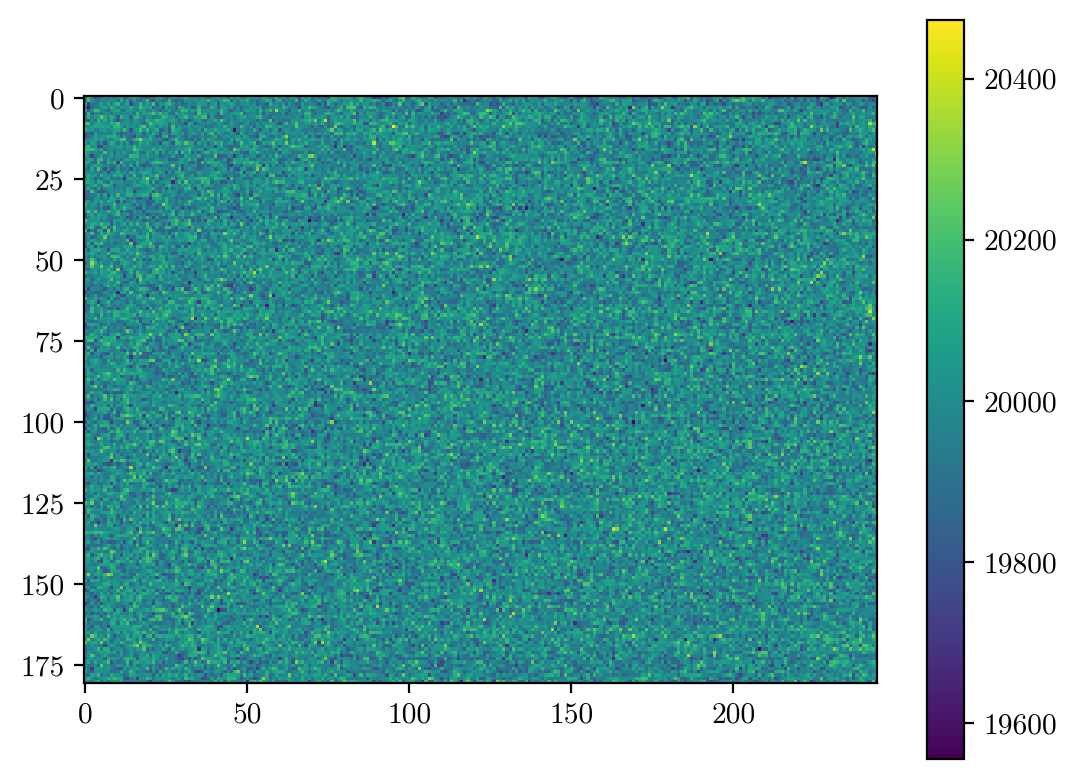

In [8]:
plt.clf()
background_sample = image[830:1011,835:1080]

plt.imshow(background_sample)
plt.colorbar()
plt.show()

In [9]:
background_sample.std(),(background_sample-2e4).std()

(np.float64(105.87939967872548), np.float64(105.87939967872548))

In [ ]:
# plt.figure()
# plt.imshow(results[0].orig_img)
# plt.figure(figsize=(20,2))

padding=128
size=128
padded_image = np.pad(results[0].orig_img,padding,mode="constant",constant_values=2e4)

# plt.axis("off")
captures = np.empty((len(res),size,size))
for i,box in enumerate(res):
    # print(box)
    x1,y1,x2,y2,_,_,z,i,x,y = box
    w,h = x2-x1,y2-y1
    if(x1 == 0):
        x1-=h-w
        w = h
    if(y1 == 0):
        y1-=w-h
        h = w
    if(x2 == 639):
        x2+=h-w
        w = h
    if(y2 == 539):
        y2+=w-h
        h = w
    x,y = 0.5*(x1+x2),0.5*(y1+y2)
    x = np.round(x).astype(int)
    y = np.round(y).astype(int)
    captures[i] = padded_image[y+padding-size//2:y+padding+size//2,x+padding-size//2:x+padding+size//2]
# captures/=
# captures-=1
downsampled_reference = (np.load("../ultralytics/data_gen/ripples_downsampled.npy")/10000)-2
true_bboxes = ops.xywh2xyxy(gt_bboxes) * np.array((512,512))[[1, 0, 1, 0]]  # target boxes
# ops.scale_boxes((512,512), gt_bbox, ori_shape, ratio_pad=ratio_pad)  # native-space labels
_, gt_pred_matcher = match_predictions(res[:,:4],true_bboxes,np.zeros(len(res)),np.zeros(len(true_bboxes)),0.5)
plt.figure(figsize=(20,2*len(captures)//11+1))
plt.figure(figsize=(20,2*len(captures)//11+1))
plt.figure(figsize=(20,2*len(captures)//11+1))
plt.figure(figsize=(20,2*len(captures)//11+1))
plt.figure(figsize=(20,2*len(captures)//11+1))
def bells(x,w,*args):
    f = np.sum([np.exp(-(w*(x-mu)**2)) for mu in args],axis=0)
    return f/np.max(f)
x = np.arange(len(downsampled_reference))
corr = []
for i,capture in enumerate(captures):

    x1,y1,x2,y2,_,_,pred_z,i,x,y = res[i]
    w,h = x2-x1,y2-y1
    v = (max(w,h)*(2)-55)
    z  = (-v/0.21)+761,(v/0.21)+761
    plt.figure(1)
    plt.suptitle("correlations+bbox")
    correlation = np.pow((downsampled_reference*(capture/10000-2)).sum(axis=(1,2)),1)
    plt.subplot(len(captures)//11+1,11,i+1)
    plt.title(str(i), y=0.77,x=0.04,loc="left",backgroundcolor="white")
    plt.plot(bells(x,5e-4,*z)*(np.max(correlation)-np.min(correlation)))
    plt.plot(correlation)
    # plt.axvline(pred_z*len(downsampled_reference), c="red")
    plt.xticks([761],["focus"])
    plt.yticks([0])
    # plt.ylim(0,0.5)c
    # plt.tight_layout()

    plt.figure(2)
    plt.suptitle("cropped image")
    plt.subplot(len(captures)//11+1,11,i+1)
    plt.title(str(i), y=0.77,x=0.04,loc="left",backgroundcolor="white")
    plt.imshow(capture,vmin=1.85e4,vmax=2.15e4)
    plt.axis("off")
    # plt.tight_layout()
    plt.figure(3)
    plt.subplot(len(captures)//11+1,11,i+1)
    plt.title(str(i), y=0.77,x=0.04,loc="left",backgroundcolor="white")
    plt.suptitle("Yolo prediction")
    plt.imshow(downsampled_reference[np.round(pred_z*len(downsampled_reference)).astype(int)],vmin=-0.05,vmax=0.05)
    plt.axis("off")

    plt.figure(4)
    plt.suptitle("ground truth")
    plt.subplot(len(captures)//11+1,11,i+1)
    plt.title(str(i), y=0.77,x=0.04,loc="left",backgroundcolor="white")

    correct_detection = np.where(gt_pred_matcher.T[i])[0]
    # if correct_detection:
    gt_image = (downsampled_reference[np.round(gt_z_values[correct_detection]*len(downsampled_reference)).astype(int)])
    # else:
    #     gt_image = np.zeros((1,128,128))
    plt.imshow(gt_image[0],vmin=-0.05,vmax=0.05)
    plt.axis("off")
    # plt.figure(4)
    # plt.suptitle("image via max correlations+bbox size")

    # plt.subplot(len(captures)//11+1,11,i+1)
    # plt.title(str(i), y=0.77,x=0.04,loc="left",backgroundcolor="white")
    # plt.imshow(downsampled_reference[np.argmax(correlation*bells(x,5e-4,*z))],vmin=-0.05,vmax=0.05)
    # corr.append(np.argmax(correlation*bells(x,5e-4,*z))/len(downsampled_reference))
    # plt.axis("off")



    # plt.colorbar()...



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [7]:
undetected = downsampled_reference[np.round(gt_z_values[np.where(gt_pred_matcher.sum(1)==0)[0]]).astype(int)]
plt.figure(figsize=(20,2))
for i,img in enumerate(undetected):
    plt.subplot(1,11,i+1)
    plt.imshow(img)
plt.show()

<Figure size 2000x200 with 0 Axes>

In [18]:

from multiprocessing import Pool
from tqdm import tqdm
import os  
subdir = 'datasets/Dataset_subpixel/'
nimages = [1196]
# nimages = [1]
folders = ['val_real']
resize_to = 540,640 #subsequent resize to have correct scale
# levels = 10
# nimages = [1000]*levels
# folders = [f'test{i}' for i in range(levels)]
# test_noiselevels = list(np.linspace(*noise_range, levels))# use noise range for train and val, and ascending noise levels for test
import time

if not os.path.exists(subdir):
    os.mkdir(subdir)

l_dir = subdir  + 'labels'
i_dir = subdir + 'images'
if not os.path.exists(i_dir):
    os.mkdir(i_dir)
if not os.path.exists(l_dir):
    os.mkdir(l_dir)
for i, prefix in enumerate(folders):
    image_dir = i_dir + '/' + prefix + '/'
    if not os.path.exists(image_dir):
        os.mkdir(image_dir)
    label_dir = l_dir + '/' + prefix + '/'
    if not os.path.exists(label_dir):
        os.mkdir(label_dir)
for i, prefix in enumerate(folders):


    # print(f"generating {prefix} data... ",end=" ", flush=True)
    vectorized_index = np.vectorize(lambda labels,item: labels.index(item))
    rngs = []
    def init():
        pass
    def call(j):
        labelname = l_dir + '/' + prefix + '/' + 'image_{:05d}.txt'.format(j,2)    
        fname = i_dir + '/' + prefix + '/' + 'image_{:05d}.tif'.format(j,2)

        img = open_yundon_img(j)
        x,y,z=np.loadtxt("../../Pictures/TrackingResultBugs_4th_TrackingGroundTruthScript250213.csv", delimiter=",").T
        x/=0.325
        y/=0.325

        z -= 0.2676 * j
        z = -z

        bw=(np.abs(z)/0.161*0.21+55)
        bh =(np.abs(z)/0.161*0.21+55)
        # print(bw/1280)
        bx = x-0*bw
        by = y-0*bh
        x /= 1280
        bx /= 1280
        bw /= 1280
        y /= 1080
        by /= 1080
        bh /= 1080
        mask = (z > -102) & (z < 108)

        cls = np.zeros_like(x)
        i = np.ones_like(x)
        
        np.savetxt(labelname, np.column_stack([cls[mask],bx[mask].clip(0,1),by[mask].clip(0,1),bw[mask].clip(0,1),bh[mask].clip(0,1),z[mask], i[mask], x[mask].clip(0,1), y[mask].clip(0,1)]), fmt='%g')
        PIL.Image.fromarray(np.array(img)).resize(resize_to[::-1]).save(fname, quality=100)
    with Pool(initializer=init) as pool:
        for _ in tqdm(pool.imap_unordered(call,range(nimages[i])),total=nimages[i], desc=prefix):
            pass
        # print(annotations)
    
        
# ig.exportConfig(subdir + 'info.txt', nimages, label_list, parameters_list, n_list, snr_range, i_range, distance, offset)

val_real: 100%|██████████| 1196/1196 [00:00<00:00, 1373.73it/s]


In [5]:
model.export(format="engine", imgsz=640)

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0


Ultralytics 8.3.51 🚀 Python-3.12.6 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4090, 24202MiB)
YOLO11n-zaxis summary (fused): 276 layers, 2,725,303 parameters, 0 gradients, 6.7 GFLOPs


RuntimeError: Given groups=1, weight of size [16, 1, 3, 3], expected input[1, 3, 640, 640] to have 1 channels, but got 3 channels instead